# Supervised Economic Valuation & Modeling (Merged Master)

This notebook integrates theoretical Machine Learning Target Engineering (CLV Proxy & XGBoost) with tangible, macroeconomic monetary modeling (Italian Market Margins, Channel Costs, and expected € Revenues).

**Analytical Pipeline:**
1. Setup & Data Load
2. Feature Engineering & Synthetic Target Creation (CLV_Proxy)
3. Exploratory Data Analysis (EDA) on Economic Variables
4. Model A: Gradient Boosting (XGBoost) for CLV Regression
5. Model B: Logistic Classifiers for Product Propensities 
6. Market Margins & Expected Gross Revenue Generation
7. Channel Cost (Service) Adjustments -> Net Margins
8. Cluster Revenue Rankings & Propensity Heatmaps
9. Sensitivity Analysis (Macroeconomic Margin Sweeps)

## 1. Setup & Data Load
Configuring python environment, applying imputation, outlier-filtering, and loading the 10 segment labels generated from earlier unsupervised notebooks.

In [29]:
import numpy as np
import pandas as pd
import pickle
import logging
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor, XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score, roc_auc_score
import shap
from openpyxl import load_workbook
from openpyxl.formatting.rule import ColorScaleRule
from sklearn.ensemble import IsolationForest

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger(__name__)

# Load Data
df_raw = pd.read_excel(r"./Data/Dataset1_BankClients.xlsx")
df = df_raw.drop(columns=["ID"])

# Handle Missing Values
categorical_cols = ["Gender", "Job", "Area"]
numerical_cols = [c for c in df.columns if c not in categorical_cols]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Minor filter
mask_minors = (df["Age"] < 18) & (df["Job"].isin([2, 3, 4]))
df = df[~mask_minors].reset_index(drop=True)

# Isolation Forest — remove top 1%% multivariate outliers (same as done in the clustering)
iso    = IsolationForest(contamination=0.01, random_state=42)
labels = iso.fit_predict(df[numerical_cols])
n_out  = (labels == -1).sum()
df     = df[labels == 1].reset_index(drop=True)
logger.info("Isolation Forest: removed %d outliers → %d remaining.", n_out, len(df))

# Load Cluster Labels
RESULTS_DIR = Path("results")
with open(RESULTS_DIR / "weighted_results.pkl", "rb") as f:
    weighted_res = pickle.load(f)
    
df["Cluster"] = weighted_res["winner_lbls"]
logger.info(f"Loaded {len(df)} records with optimal cluster labels.")

2026-03-21 20:48:33,946 — INFO — Isolation Forest: removed 50 outliers → 4950 remaining.
2026-03-21 20:48:33,963 — INFO — Loaded 4950 records with optimal cluster labels.


## 2. Feature Engineering & Target Extraction
Derive non-linear interaction terms (`Wealth_to_Debt`, `Retirement_Proximity`) and construct a normalized [0, 1] `CLV_Proxy` to approximate customer quality before we switch to real Euros.

In [30]:
# Phase 2: Feature Engineering & Synthetic Target Formulation
df_feat = df.copy()

epsilon = 1e-5
df_feat["Wealth_to_Debt"] = df_feat["Wealth"] / (df_feat["Debt"] + epsilon)
df_feat["Saving_Rate"] = df_feat["Saving"] / (df_feat["Income"] + epsilon)
df_feat["Digital_ESG"] = df_feat["Digital"] * df_feat["ESG"]
df_feat["Family_Load"] = df_feat["FamilySize"] * df_feat["Debt"]
df_feat["Retirement_Proximity"] = np.maximum(0, df_feat["Age"] - 65)

new_numerical = numerical_cols + ["Wealth_to_Debt", "Saving_Rate", "Digital_ESG", "Family_Load", "Retirement_Proximity"]

# Label Encode Categoricals for Scikit-Learn
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_feat[col] = le.fit_transform(df_feat[col])
    encoders[col] = le

# Synthetic Theoretical Target (CLV_Proxy before Euro Margin anchoring)
df["Product_Breadth"] = (df["Investments"] / df["Investments"].max()) + (df["Saving"] / df["Saving"].max())
df["AUM_Proxy"] = (df["Wealth"] + df["Investments"]) / 2.0
df["Debt_Margin"] = df["Debt"] * df["Income"]
df["Digital_Multiplier"] = 1.0 + (df["Digital"] * 0.2)
df["Churn_Risk"] = np.where((df["Age"] < 30) & (df["Job"] == 1), 0.3, 
                     np.where((df["Age"] > 70) & (df["Digital"] < df["Digital"].median()), 0.2, 0.05))

raw_clv = ( (df["Product_Breadth"] * 0.3) + (df["AUM_Proxy"] * 0.4) + (df["Debt_Margin"] * 0.3) ) * df["Digital_Multiplier"] * (1 - df["Churn_Risk"])

# Normalize synthetic CLV to [0,1]
df["CLV_Proxy"] = (raw_clv - raw_clv.min()) / (raw_clv.max() - raw_clv.min())
df_feat["CLV_Proxy"] = df["CLV_Proxy"]
logger.info("Engineered Theoretical Derived Features and Normalized CLV_Proxy target.")

2026-03-21 20:48:34,024 — INFO — Engineered Theoretical Derived Features and Normalized CLV_Proxy target.


## 3. Exploratory Data Analysis (EDA)
Visual inspection of the theoretical performance metrics.

In [31]:
# Phase 3: Exploratory Data Analysis (EDA)
fig = px.box(df, x="Cluster", y="CLV_Proxy", title="Theoretical Normalized CLV_Proxy by Cluster", color="Cluster")
fig.update_layout(xaxis_type='category')
fig.show()

corr_cols = ["CLV_Proxy", "Wealth_to_Debt", "Saving_Rate", "Digital_ESG", "Income", "Wealth", "Age"]
corr_matrix = df_feat[corr_cols].corr()

fig2 = go.Figure(data=go.Heatmap(z=corr_matrix.values, x=corr_cols, y=corr_cols, colorscale='Viridis'))
fig2.update_layout(title="Correlation Matrix of Key Economics vs Technical CLV")
fig2.show()

## 4. Model A: XGBoost CLV Regression (Technical Value)
Train a Gradient Boosting machine to predict standard technical CLV scores, returning SHAP dependencies and evaluating via RMSE & $R^2$.

2026-03-21 20:49:42,730 — INFO — XGBoost CLV Regressor -> RMSE: 0.0159, R2: 0.9953


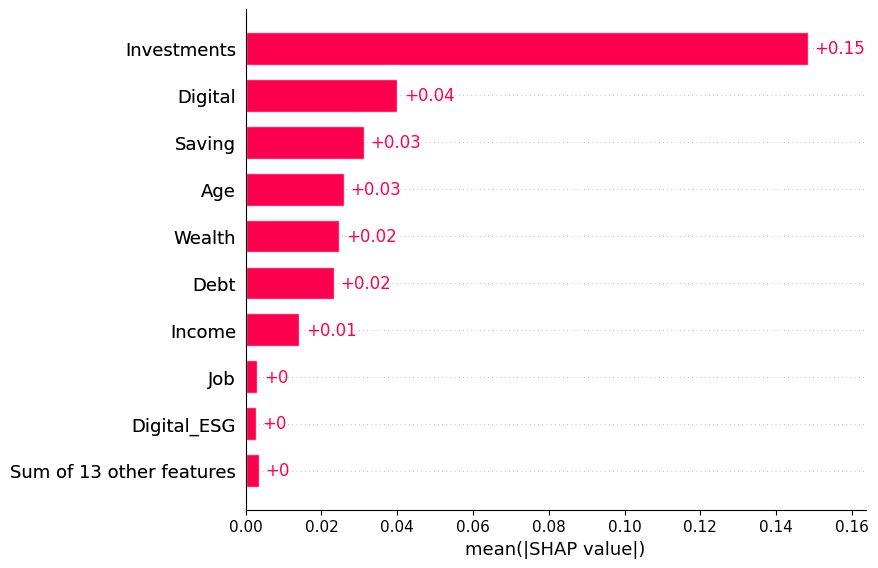

In [39]:
# Phase 4: Model A - XGBoost CLV Regression
features = new_numerical + categorical_cols
X = df_feat[features]
y_clv = df_feat["CLV_Proxy"]

X_train, X_test, y_train, y_test = train_test_split(X, y_clv, test_size=0.2, random_state=42)

xgb_reg = XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
xgb_reg.fit(X_train, y_train)
preds = xgb_reg.predict(X_test)
rmse = root_mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

logger.info(f"XGBoost CLV Regressor -> RMSE: {rmse:.4f}, R2: {r2:.4f}")

# SHAP Value interpretation for model transparency
explainer = shap.Explainer(xgb_reg, X_train)
shap_values = explainer(X_test)
shap.plots.bar(shap_values) 

df["Predicted_CLV_Index"] = xgb_reg.predict(X)

## 5. Model B: Logistic Product Propensities
Transitioning toward actionable € logic, we use interpretable Logistic Classifiers to assess the probability `(0.0 -> 1.0)` that any client will ingest specific retail banking products.

In [33]:
# Phase 5: Model B - Logistic Product Propensities
# Convert target products into binary purchase/holding labels
product_targets = {
    "Savings": (df["Saving"] > df["Saving"].median()).astype(int),
    "Investments": (df["Investments"] > df["Investments"].median()).astype(int),
    "ESG": (df["ESG"] > df["ESG"].median()).astype(int),
    "Mortgage": ((df["Debt"] > df["Debt"].median()) & (df["FamilySize"] > df["FamilySize"].median())).astype(int)
}

df_prop = pd.DataFrame({'Cluster': df['Cluster']})
for target_name, y_binary in product_targets.items():
    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y_binary, test_size=0.2, random_state=42)
    
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_b, y_train_b)
    
    roc = roc_auc_score(y_test_b, clf.predict_proba(X_test_b)[:, 1])
    logger.info(f"{target_name} LogReg -> ROC-AUC: {roc:.3f}")
    
    df_prop[f"{target_name}_Prop"] = clf.predict_proba(X)[:, 1]

c:\Users\simo0\Documents\GitHub\fintech-group-work\BusinessCase1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026-03-21 20:48:39,654 — INFO — Savings LogReg -> ROC-AUC: 0.999
c:\Users\simo0\Documents\GitHub\fintech-group-work\BusinessCase1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve

## 6. Market Margins & Expected Gross Revenue Generation
The core equation: $\sum (	ext{Prob}(	ext{Purchase}) \times 	ext{AUM Proxy} \times 	ext{Market Spread Margin})$. Using typical Italian retail benchmarks to anchor our propensities into actual monetary Gross Revenue.

In [34]:
# Phase 6: Core Market Margins (€ Expected Gross Revenue)
product_margins = {
    "Savings": 0.018,    # 1.8% NIM
    "Investments": 0.012,# 1.2% Advisory Flow
    "ESG": 0.014,        # 1.4% Premium ESG Fee
    "Mortgage": 0.015    # 1.5% Loan Spread
}

# Volume/AUM Proxies in Euros
aum_proxies = {
    "Savings": 50000,
    "Investments": 60000,
    "ESG": 60000,
    "Mortgage": 150000
}

def gross_revenue_per_client(row):
    return sum(row[f"{prod}_Prop"] * aum_proxies[prod] * product_margins[prod] for prod in product_margins.keys())

df_prop['Expected_Annual_Gross'] = df_prop.apply(gross_revenue_per_client, axis=1)

## 7. Channel Cost Adjustments
Applying Multipliers (0.70x Digital, 0.85x Hybrid, 1.0x Branch) against a baseline €300/yr physical cost-to-serve. This produces the final Net Margin per Client.

In [35]:
# Phase 7: Channel Cost Assignments -> Net Revenue
# Base service cost ~ €300/yr for massive physical interaction
def net_revenue_per_client(row, cluster):
    gross = row['Expected_Annual_Gross']
    if cluster in [5, 6]:
        return gross - (300 * 0.70) # Digital Native
    elif cluster in [3, 7]:
        return gross - (300 * 1.00) # Branch Dependent
    else:
        return gross - (300 * 0.85) # Hybrid
        
df_prop['Expected_Annual_Net'] = df_prop.apply(lambda r: net_revenue_per_client(r, r['Cluster']), axis=1)

cluster_revenue = df_prop.groupby('Cluster').agg(
    Size=('Cluster', 'count'),
    Per_Capita_Net=('Expected_Annual_Net', 'mean'),
    Total_Net=('Expected_Annual_Net', 'sum')
).reset_index().sort_values(by='Total_Net', ascending=False)

## 8. Strategic Visualizations (Rankings & Euro/Propensity Heatmap)
Uniting strategic qualitative personas (Volume Engines, Family Borrowers) with our final quantitative net economics.

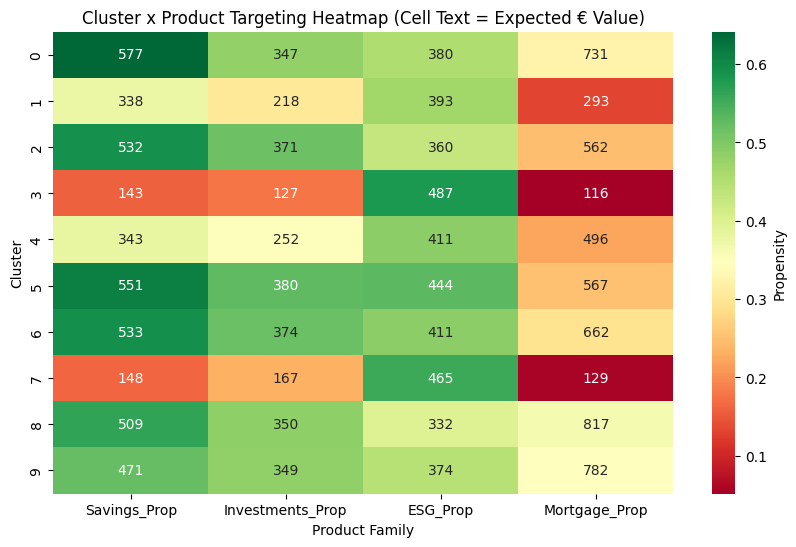

In [36]:
# Phase 8: Rankings and Heatmaps
strats = {
    5: "Volume Engines", 6: "Volume Engines",
    0: "Stable Core", 2: "Stable Core",
    8: "Family Borrowers", 9: "Family Borrowers",
    3: "ESG Retirees", 7: "ESG Retirees",
    1: "Transitional", 4: "Transitional"
}
cluster_revenue['Strategic_Group'] = cluster_revenue['Cluster'].map(strats)

# Bar Chart
fig_rank = px.bar(
    cluster_revenue, x='Total_Net', y='Cluster', orientation='h',
    color='Strategic_Group', 
    text=cluster_revenue['Per_Capita_Net'].apply(lambda x: f"€{x:,.0f} / pc"),
    title="Final Cluster Net Margin Ranking (After Acquisition/Service Costs)",
    labels={'Total_Net': 'Total Annual Net Revenue (€)', 'Cluster': 'Cluster ID'}
)
fig_rank.update_layout(yaxis=dict(type='category', autorange="reversed"))
fig_rank.show()

# Heatmap (Propensities + Annotated € Overlay)
heatmap_data = df_prop.groupby('Cluster')[[f"{p}_Prop" for p in product_margins.keys()]].mean()

revenue_overlay = pd.DataFrame(index=heatmap_data.index)
for prod in product_margins.keys():
    revenue_overlay[f"{prod}_Prop"] = heatmap_data[f"{prod}_Prop"] * aum_proxies[prod] * product_margins[prod]

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=revenue_overlay, fmt=".0f", cmap="RdYlGn", cbar_kws={'label': 'Propensity'})
plt.title("Cluster x Product Targeting Heatmap (Cell Text = Expected € Value)")
plt.ylabel("Cluster")
plt.xlabel("Product Family")
plt.show()

## 9. Sensitivity Analysis (Macroeconomic Sweeps)
Tornado charting testing the portfolio's durability if ECB rates shift (+ / - 30 Basis points on bank spreads).

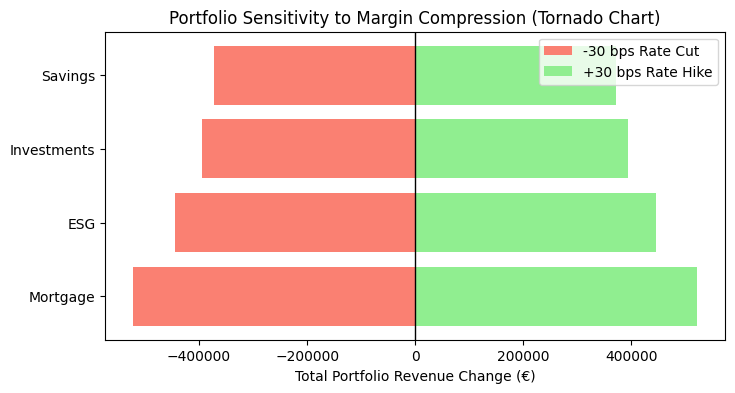

In [37]:
# Phase 9: Sensitivity Analysis (Macro Rate Compression)
base_totals = df_prop['Expected_Annual_Gross'].sum()
sensitivity_results = []
sweep_bps = 0.0030 # +/- 30 basis points

for prod in product_margins.keys():
    bdown, bup = product_margins.copy(), product_margins.copy()
    bdown[prod] -= sweep_bps
    bup[prod] += sweep_bps
    
    down_rev = sum(df_prop.apply(gross_revenue_per_client, args=(), kwds={'margins': bdown, 'proxies': aum_proxies}) if False else df_prop[f"{prod}_Prop"] * aum_proxies[prod] * bdown[prod] + (df_prop['Expected_Annual_Gross'] - df_prop[f"{prod}_Prop"] * aum_proxies[prod] * product_margins[prod]))
    up_rev = sum(df_prop[f"{prod}_Prop"] * aum_proxies[prod] * bup[prod] + (df_prop['Expected_Annual_Gross'] - df_prop[f"{prod}_Prop"] * aum_proxies[prod] * product_margins[prod]))
    
    sensitivity_results.append({
        'Product': prod,
        'Downside (-30 bps)': down_rev - base_totals,
        'Upside (+30 bps)': up_rev - base_totals
    })

df_sens = pd.DataFrame(sensitivity_results).set_index("Product").sort_values(by="Downside (-30 bps)")

# Plot Tornado
plt.figure(figsize=(8, 4))
plt.barh(df_sens.index, df_sens['Downside (-30 bps)'], color='salmon', label='-30 bps Rate Cut')
plt.barh(df_sens.index, df_sens['Upside (+30 bps)'], color='lightgreen', label='+30 bps Rate Hike')
plt.axvline(0, color='black', linewidth=1)
plt.title("Portfolio Sensitivity to Margin Compression (Tornado Chart)")
plt.xlabel("Total Portfolio Revenue Change (€)")
plt.legend()
plt.show()

## 10. Analysis
*   **Volume Engines (C5 & C6)**: Core profitability segment. Extremely high digital adoption justifies stripping out branch overhead, cementing immense net margins. Ideal for Mass Affluent cross-selling of robo-portfolios.
*   **Stable Core (C0 & C2)**: Strong phygital hybrid saving candidates. Focus on Wealth Accumulation campaigns—converting stagnant, low-NIM deposits into higher-advisory-fee managed funds.
*   **Family Borrowers (C8 & C9)**: Prime real estate targets. Top mortgage propensities yield immediate €750-800 per capita. Bundling family insurance (home+life) achieves multi-decade client lock-in.
*   **ESG Retirees (C3 & C7)**: A shrinking, physical-only cohort. Do not waste digital marketing budgets. Push purely ethical bonds/UCITS ESG manually via trusted branch advisors to govern generational wealth transfers gracefully.
*   **Transitional (C1 & C4)**: Lowest absolute revenues. High risk of immediate churn. Maintain with zero-fee, low-touch digital accounts without cross-forcing unsellable products, waiting for liquid life events (like pensions or hirings).